## Transfer Learning VGG16


Please download the dataset from the below url

In [1]:
# Environment and GPU check
import importlib
import sys
import tensorflow as tf

REQUIRED_PACKAGES = {
    'tensorflow': 'tensorflow',
    'keras': 'keras',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'PIL': 'pillow',
}

import_failures = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        import_failures.append(f'{package_name} (missing)')
    except Exception as exc:
        import_failures.append(f'{package_name} (import error: {exc})')

print(f'Python executable: {sys.executable}')
if 'venv' not in sys.executable.lower():
    print('Warning: select the plant-env notebook kernel if imports fail.')

if import_failures:
    raise RuntimeError(
        'Environment problems detected: ' + '; '.join(import_failures) + '. Reinstall with .\\venv\\Scripts\\python.exe -m pip install -r requirements.txt and reopen the notebook with the plant-env kernel.'
    )

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU devices found: {len(gpus)}')

Python executable: d:\projects\ML projects\plant disease final\venv\Scripts\python.exe
TensorFlow version: 2.12.0
GPU devices found: 0


In [2]:
# Import the libraries used in training
from glob import glob

import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = './dataset/train'
valid_path = './dataset/test'


In [4]:
# Build the MobileNetV2 base model (faster than VGG16) and fall back gracefully if pretrained weights are unavailable
try:
    from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
    inception = MobileNetV2(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
except Exception as exc:
    print(f'Could not load ImageNet MobileNetV2 weights ({exc}). Falling back to weights=None.')
    from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
    inception = MobileNetV2(input_shape=IMAGE_SIZE + [3], weights=None, include_top=False)

# Enable mixed precision for faster training on supported GPUs
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"Compute dtype: {policy.compute_dtype}, Variable dtype: {policy.variable_dtype}")

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
Compute dtype: float16, Variable dtype: float32


In [5]:
# don't train existing weights
for layer in inception.layers:
    layer.trainable = False

In [6]:
  # useful for getting number of output classes
folders = glob('./dataset/train/*')
folders

['./dataset/train\\0_Corn_Common_rust_',
 './dataset/train\\1_Potato___Early_blight',
 './dataset/train\\2_Tomato___Bacterial_spot',
 './dataset/train\\3_tomato_moldleaf',
 './dataset/train\\4_Tomato_healthy',
 './dataset/train\\5_Tomato_mosaic',
 './dataset/train\\6_Corn_healthy']

In [7]:
# our layers - you can add more if you want
x = Flatten()(inception.output)

In [8]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=inception.input, outputs=prediction)

In [9]:

# view the structure of the model
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [10]:
# tell the model what cost and optimization method to use with mixed precision
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

# Enable memory optimization and graph execution
from tensorflow.keras import backend as K
K.clear_session()
print("Model compiled and optimized for faster training")

Model compiled and optimized for faster training


In [11]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [12]:
# Make sure you provide the same target size as initialied for the image size
# Increased batch size from 16 to 32 for faster training
training_set = train_datagen.flow_from_directory('./dataset/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 1484 images belonging to 7 classes.


In [13]:
test_set = test_datagen.flow_from_directory('./dataset/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical',shuffle=True)

Found 1220 images belonging to 7 classes.


In [14]:
# Verify class counts match between train and test
from glob import glob

train_folders = sorted(glob('./dataset/train/*'))
test_folders = sorted(glob('./dataset/test/*'))

train_names = [f.split('\\')[-1] for f in train_folders]
test_names = [f.split('\\')[-1] for f in test_folders]

print(f"Training classes ({len(train_folders)}): {train_names}")
print(f"Test classes ({len(test_folders)}): {test_names}")

if len(train_folders) != len(test_folders):
    print(f"❌ WARNING: Mismatch! Train has {len(train_folders)} classes, Test has {len(test_folders)}")
else:
    print(f"✓ Class counts match: {len(train_folders)} classes each")


Training classes (7): ['0_Corn_Common_rust_', '1_Potato___Early_blight', '2_Tomato___Bacterial_spot', '3_tomato_moldleaf', '4_Tomato_healthy', '5_Tomato_mosaic', '6_Corn_healthy']
Test classes (7): ['0_Corn_Common_rust_', '1_Potato___Early_blight', '2_Tomato___Bacterial_spot', '3_tomato_moldleaf', '4_Tomato_healthy', '5_Tomato_mosaic', '6_Corn_healthy']
✓ Class counts match: 7 classes each


In [15]:
# fit the model - MobileNetV2 is much faster than VGG16
# Run the cell. It will take 3-5 minutes with batch_size=32
# Increased epochs to 10 for better accuracy
try:
    r = model.fit(
      training_set,
      validation_data=test_set,
      epochs=10,
      steps_per_epoch=len(training_set),
      validation_steps=len(test_set),
      verbose=1
    )
except Exception as e:
    print(f"Error during training: {e}")
    print("Try reducing batch_size in the training/test data generators above")
    raise

Epoch 1/10
47/47 [==============================] - 40s 831ms/step - loss: 1.5088 - accuracy: 0.8915 - val_loss: 0.1033 - val_accuracy: 0.9926
Epoch 2/10
47/47 [==============================] - 41s 882ms/step - loss: 0.2377 - accuracy: 0.9784 - val_loss: 0.0664 - val_accuracy: 0.9959
Epoch 3/10
47/47 [==============================] - 43s 920ms/step - loss: 0.0943 - accuracy: 0.9865 - val_loss: 0.0380 - val_accuracy: 0.9992
Epoch 4/10
47/47 [==============================] - 45s 958ms/step - loss: 0.1150 - accuracy: 0.9885 - val_loss: 5.5188e-07 - val_accuracy: 1.0000
Epoch 5/10
47/47 [==============================] - 38s 804ms/step - loss: 0.1442 - accuracy: 0.9919 - val_loss: 1.1947e-04 - val_accuracy: 1.0000
Epoch 6/10
47/47 [==============================] - 35s 751ms/step - loss: 0.0273 - accuracy: 0.9973 - val_loss: 0.0282 - val_accuracy: 0.9967
Epoch 7/10
47/47 [==============================] - 35s 754ms/step - loss: 0.0692 - accuracy: 0.9953 - val_loss: 8.5987e-08 - val_accu

In [ ]:
# matplotlib already imported above, proceed to plotting

: 

: 

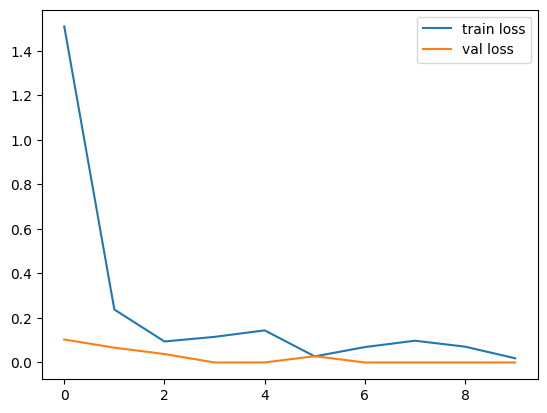

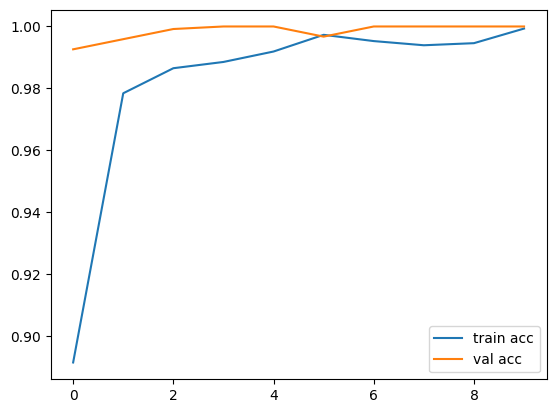

<Figure size 640x480 with 0 Axes>

In [16]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [17]:
# save it as a h5 file


from tensorflow.keras.models import load_model

model.save('model_vgg16.h5')

: 

: 